# Van der Waals dispersion: Grimme's D2

A semilocal functional cannot see a van der Waals bond. Its correlation energy is a
functional of the density *where the orbitals are*, and the London force comes from the
correlated fluctuations of two charge distributions that do not overlap at all. Bilayer
graphene is the canonical demonstration: **PBE alone gives it no minimum in the interlayer
separation**, and the two layers drift apart.

Grimme's D2 ([J. Comp. Chem. **27**, 1787 (2006)](https://doi.org/10.1002/jcc.20495)) puts
the attraction back as a pair potential over the nuclei,

$$E_{\rm disp} = -\frac{s_6}{2} \sum_{i \neq j} \sum_{\mathbf L}
   \frac{C_6^{ij}}{|\mathbf r_{ij} + \mathbf L|^6}\;
   f_{\rm damp}\!\big(|\mathbf r_{ij} + \mathbf L|\big),
\qquad
f_{\rm damp}(R) = \frac{1}{1 + e^{-d\,(R/R_{\rm vdW} - 1)}}$$

with $C_6^{ij} = \sqrt{C_6^i C_6^j}$ from a table indexed by atomic number. The damping
function switches the $R^{-6}$ tail off where the two densities begin to overlap and the
functional is already describing the interaction. It is the Ewald sum with a different
radial function: a pair sum over the nuclei and their periodic images, and nothing else.

Against `pw.x` on the same input:

| | defumat | `pw.x` |
|---|---|---|
| total energy | **-45.10439956 Ry** | agrees to 3.1e-9 |
| $E_{\rm disp}$ | **-0.02305929 Ry** | agrees to 4.9e-9 |
| force | | agrees to 3.7e-7 Ry/bohr |
| stress | | agrees to 4.1e-8 Ry/bohr³ |

And the relaxation binds the bilayer at **6.10 bohr (3.23 Å)**, against a measured 3.35 Å,
where PBE alone has no minimum at all.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from defumat import Calculator
from defumat.io import comparison_table, read_qe_output

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

bilayer = Calculator.from_file(CASES / "graphene-bilayer-d2.in", pseudo_dir=PSEUDO,
                               announce=False)
graphite = bilayer.get_scf()
print("bilayer graphene, PBE + D2:   E = %.8f Ry,   E_disp = %.8f Ry"
      % (graphite.total_energy, graphite.energy_terms["dispersion"]))

bilayer graphene, PBE + D2:   E = -45.10439956 Ry,   E_disp = -0.02305929 Ry


## It is a function of the nuclei, and of nothing else

D2 never sees the electron density, which has a consequence sharper than any tolerance: the
density, the eigenvalues and the potential of a run with the correction are **bit for bit**
what the same run without it produces, and the two total energies differ by exactly the
dispersion energy. That is what distinguishes a correction of this kind from one that enters
the self-consistent potential, and it is what makes the electronic and the dispersion
energies separately meaningful. Term by term against `pw.x` on the same input -- where the
Hartree and one-electron entries are each about 2e-5 out and their sum is 3e-9, these two
being the large opposing electrostatic terms and only their total being a physical quantity:

In [2]:
qe = read_qe_output(CASES / "reference.out.graphene-bilayer-d2")

rows = [(name, value, qe.energy_terms.get(name))
        for name, value in sorted(graphite.energy_terms.items())]
rows.append(("total", graphite.total_energy, qe.total_energy))
print(comparison_table(rows, fmt="{:.8f}",
                       headers=("term", "defumat [Ry]", "pw.x", "difference")))

term          defumat [Ry]          pw.x  difference
dispersion      -0.02305929   -0.02305929     4.9e-09
ewald           11.66546446   11.66546446     7.9e-10
hartree         53.78898878   53.78896923     2.0e-05
one-electron   -96.54077121  -96.54075437     1.7e-05
smearing        -0.00021298   -0.00021298     2.2e-09
xc             -13.99480933  -13.99480662     2.7e-06
total          -45.10439956  -45.10439956     3.1e-09


## What the correction is for

Because the self-consistent loop never sees it, one sweep of runs gives both curves at once:
the PBE energies below were measured offline, and the dispersion energy at each separation is
recomputed here, because it is a pair sum over four nuclei and costs milliseconds.

PBE alone is repulsive all the way out. $E_{\rm disp}$ is *monotonic* and has no minimum of
its own. Their sum has one, and that is the whole mechanism: the binding is the balance
between an attractive tail and the functional's own wall.

The sweep stops at 10 bohr and the curves are referred to that point rather than to infinity,
because the cell is 20 bohr tall -- at a separation of 10 bohr each layer is equidistant from
its neighbour and from its own periodic image, and past that the two swap roles. The binding
energy is therefore a lower bound on the well depth.

In [3]:
# Eleven self-consistent runs at ecutwfc = 40 on a 12x12x1 grid, measured offline (Ry).
SEPARATION = np.array([5.4, 5.7, 6.0, 6.1, 6.3, 6.6, 7.0, 7.5, 8.0, 9.0, 10.0])
E_PBE = np.array([-45.06839999, -45.0745402, -45.07779712, -45.07857165, -45.0793757,
                  -45.08052449, -45.08134049, -45.08141908, -45.08163641, -45.08156401,
                  -45.08157174])

pairs = bilayer.calculation.dispersion_sum
at = np.asarray(bilayer.system.cell.at)
crystal = np.asarray(bilayer.system.structure.positions) @ np.linalg.inv(at)

def dispersion_at(separation):
    "The pair sum with the two layers this far apart: no self-consistent run at all."
    moved = crystal.copy()
    moved[:2, 2] = 0.5 - 0.5 * separation / at[2, 2]
    moved[2:, 2] = 0.5 + 0.5 * separation / at[2, 2]
    return float(pairs.energy(moved @ at))

E_DISP = np.array([dispersion_at(d) for d in SEPARATION])
meV = lambda y: (y - y[-1]) * 13605.7
print("well depth   %.1f meV per atom (a lower bound);   minimum of the sweep at %.2f bohr"
      % (-meV(E_PBE + E_DISP).min() / 4, SEPARATION[(E_PBE + E_DISP).argmin()]))

well depth   17.8 meV per atom (a lower bound);   minimum of the sweep at 6.10 bohr


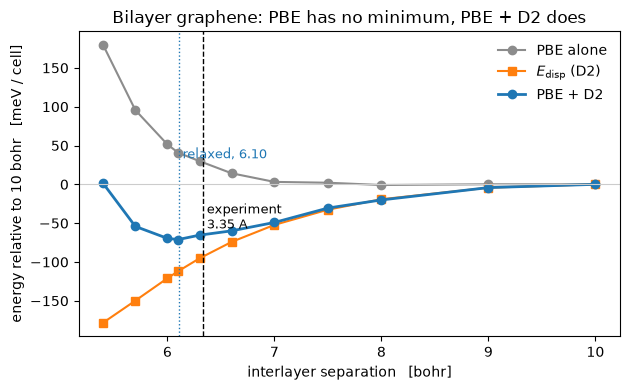

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(SEPARATION, meV(E_PBE), "o-", color="0.55", label="PBE alone")
ax.plot(SEPARATION, meV(E_DISP), "s-", color="tab:orange", label=r"$E_{\rm disp}$ (D2)")
ax.plot(SEPARATION, meV(E_PBE + E_DISP), "o-", color="tab:blue", lw=2, label="PBE + D2")
ax.axvline(6.104, color="tab:blue", ls=":", lw=1)
ax.axvline(3.35 * 1.8897259886, color="k", ls="--", lw=1)
ax.annotate(" relaxed, 6.10", xy=(6.104, 0.62), xycoords=("data", "axes fraction"),
            color="tab:blue", fontsize=9, va="top")
ax.annotate(" experiment\n 3.35 A", xy=(3.35 * 1.8897259886, 0.44),
            xycoords=("data", "axes fraction"), fontsize=9, va="top")
ax.axhline(0.0, color="0.8", lw=0.8)
ax.set_xlabel("interlayer separation   [bohr]")
ax.set_ylabel("energy relative to 10 bohr   [meV / cell]")
ax.set_title("Bilayer graphene: PBE has no minimum, PBE + D2 does")
ax.legend(frameon=False)
fig.tight_layout()

## What it moves, and what it cannot touch

The force and the stress are derivatives of that same pair sum, in the positions and in the
strain that deforms the lattice translations, so both reach `get_forces()` and `get_stress()`
without anything further being written. Because the stress moves, everything built on it
moves too, including the **elastic constants**; because the Hamiltonian does not, nothing
built on the electronic response moves at all.

That makes the effect of a dispersion correction on an electrostriction tensor predictable in
advance. Measured on the silicon case of notebook 21 with D2 switched on, which is unphysical
and exactly the point:

| | no D2 | with D2 | difference |
|---|---|---|---|
| $C_{11}$ (GPa) | 209.377 | 206.553 | -2.824 |
| $C_{12}$ (GPa) | 67.976 | 67.134 | -0.842 |
| $C_{44}$ (GPa) | 133.962 | 134.628 | +0.666 |
| $d\chi_{11}/dx_{11}$ | 197.015 | 197.015 | **0.0** |

**Every entry in the elastic column is negative, and that is not a mistake.** The D2 pair
potential has no minimum of its own: in its attractive tail $E \sim -C_6/R^6$ has
$d^2E/dR^2 < 0$ everywhere. What binds the bilayer is D2's slope against PBE's, not its
curvature, so its contribution to the elastic constants is a *softening*. The positive
$C_{33}$ of the relaxed bilayer comes from PBE's repulsive wall; D2 moves where that wall is
met and takes a couple of GPa off the stiffness once it is.

## What is not here

Four of the five corrections are refused rather than silently substituted, and the reason
splits them cleanly in two. **D3**'s $C_6$ coefficients depend on each atom's coordination
number, so they are functions of the geometry with derivatives of their own rather than table
entries. **Tkatchenko-Scheffler**, **MBD** and **XDM** rescale their coefficients by
quantities built from the self-consistent density, Hirshfeld volumes or the exchange hole,
which puts them inside the self-consistent potential where D2 sits outside it, and the
identity above is precisely what would stop holding.

---
The tests behind this notebook: `tests/regression/test_dispersion.py`, which holds the
bit-for-bit identity between the corrected and the uncorrected density, the force and stress
against QE's own dispersion blocks, the relaxation that binds the layers, and the elastic
constants picking up exactly the pair sum's second derivative; and
`tests/unit/test_dispersion.py`, which holds the tabulated coefficients, the cutoff
convergence and each of the four refusals.